# Preprocessing and EDA for DDI LD50 Smyth Dataset

This notebook:
- Load and inspect the DDI LD₅₀ dataset

- Validate and clean LD₅₀ values for both individual drugs and mixtures

- Compute molecular weights from SMILES_A and SMILES_B

- Convert toxicity values from mg/kg to −log₁₀(mol/kg)

- Perform exploratory data analysis (EDA) on transformed toxicity values

- Generate processed and model-ready datasets for downstream modeling


In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 11.7 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load the dataset

In [4]:
file_path = '/content/drive/MyDrive/FYP/IRP/Data/ddi_ld50_smyth/ddi_ld50_smyth_final_mgkg.csv'
df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (350, 7)


,DrugA,DrugB,SMILES_A,SMILES_B,LD50_A_mg/kg,LD50_B_mg/kg,Mixture_LD50_mg/kg
0,Acetone,Acetonitrile,CC(=O)C,CC#N,8760.6,6500.22,2055.6535
1,Acetone,Acetophenone,CC(=O)C,CC(=O)c1ccccc1,8760.6,2549.44,3091.1650
2,Acetone,Acrylonitrile,CC(=O)C,C=CC#N,8760.6,112.84,187.7380
3,Acetone,Aniline,CC(=O)C,Nc1ccccc1,8760.6,725.62,1386.8725
4,Acetone,Butyl Cellosolve,CC(=O)C,CCCCOCCO,8760.6,2146.76,3064.4355


## 2. Initial inspection and cleaning

In [5]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DrugA               350 non-null    object 
 1   DrugB               350 non-null    object 
 2   SMILES_A            350 non-null    object 
 3   SMILES_B            350 non-null    object 
 4   LD50_A_mg/kg        350 non-null    float64
 5   LD50_B_mg/kg        350 non-null    float64
 6   Mixture_LD50_mg/kg  350 non-null    float64
dtypes: float64(3), object(4)
memory usage: 19.3+ KB


In [6]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])

Missing values per column:
 Series([], dtype: int64)


In [7]:
# Convert LD50 columns to numeric
for col in ['LD50_A_mg/kg', 'LD50_B_mg/kg', 'Mixture_LD50_mg/kg']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [8]:
df = df.dropna(subset=['LD50_A_mg/kg', 'LD50_B_mg/kg', 'Mixture_LD50_mg/kg']).copy()
print(f"Shape after cleaning: {df.shape}")

Shape after cleaning: (350, 7)


## 3. Compute molecular weights from SMILES

In [9]:
def mol_weight_from_smiles(smiles):
    """Calculate molecular weight from SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan
    return Descriptors.MolWt(mol)

df['MW_A'] = df['SMILES_A'].apply(mol_weight_from_smiles)
df['MW_B'] = df['SMILES_B'].apply(mol_weight_from_smiles)

print(f"Number with valid MW_A: {df['MW_A'].notna().sum()}")
print(f"Number with valid MW_B: {df['MW_B'].notna().sum()}")

# Drop rows where either MW is missing
df = df.dropna(subset=['MW_A', 'MW_B']).copy()
print(f"Shape after dropping invalid MW: {df.shape}")

Number with valid MW_A: 350
Number with valid MW_B: 350
Shape after dropping invalid MW: (350, 9)


 ## 4. Convert mg/kg to −log₁₀(mol/kg)

Formula:  log₁₀( (LD50 in mg/kg) / (1000 * MW) )

In [10]:
def convert_to_neglog_molkg(ld50_mgkg, mw):
    """Convert LD50 from mg/kg to -log10(mol/kg)."""
    molkg = ld50_mgkg / (1000.0 * mw)
    if molkg <= 0:
        return np.nan
    return -np.log10(molkg)

df['LD50_A_neglog'] = df.apply(lambda row: convert_to_neglog_molkg(row['LD50_A_mg/kg'], row['MW_A']), axis=1)
df['LD50_B_neglog'] = df.apply(lambda row: convert_to_neglog_molkg(row['LD50_B_mg/kg'], row['MW_B']), axis=1)
df['Mixture_neglog'] = df.apply(lambda row: convert_to_neglog_molkg(row['Mixture_LD50_mg/kg'], (row['MW_A'] + row['MW_B']) / 2), axis=1)
# Note: For mixture, a combined molecular weight could be ambiguous; using average of the two MWs as an approximation.

# Drop rows where conversion failed (should be none)
df = df.dropna(subset=['LD50_A_neglog', 'LD50_B_neglog', 'Mixture_neglog']).copy()
print(f"Shape after conversion: {df.shape}")
df[['DrugA', 'DrugB', 'SMILES_A', 'SMILES_B', 'LD50_A_neglog', 'LD50_B_neglog', 'Mixture_neglog']].head()

Shape after conversion: (350, 12)


,DrugA,DrugB,SMILES_A,SMILES_B,LD50_A_neglog,LD50_B_neglog,Mixture_neglog
0,Acetone,Acetonitrile,CC(=O)C,CC#N,0.821493,0.800417,1.382238
1,Acetone,Acetophenone,CC(=O)C,CC(=O)c1ccccc1,0.821493,1.673283,1.459831
2,Acetone,Acrylonitrile,CC(=O)C,C=CC#N,0.821493,2.672337,2.471304
3,Acetone,Aniline,CC(=O)C,Nc1ccccc1,0.821493,2.108376,1.736511
4,Acetone,Butyl Cellosolve,CC(=O)C,CCCCOCCO,0.821493,1.740746,1.458763


## 6. Exploratory Data Analysis

In [11]:
# Basic statistics of the converted values
print("Statistics of converted LD50 values:")
print(df[['LD50_A_neglog', 'LD50_B_neglog', 'Mixture_neglog']].describe())

Statistics of converted LD50 values:
       LD50_A_neglog  LD50_B_neglog  Mixture_neglog
count     350.000000     350.000000      350.000000
mean        1.465339       1.383994        1.574540
std         0.609126       0.534891        0.477229
min         0.219593       0.219593        0.146880
25%         0.936140       1.106533        1.268911
50%         1.495982       1.220633        1.586394
75%         1.966711       1.743702        1.871728
max         2.672337       2.672337        3.072175


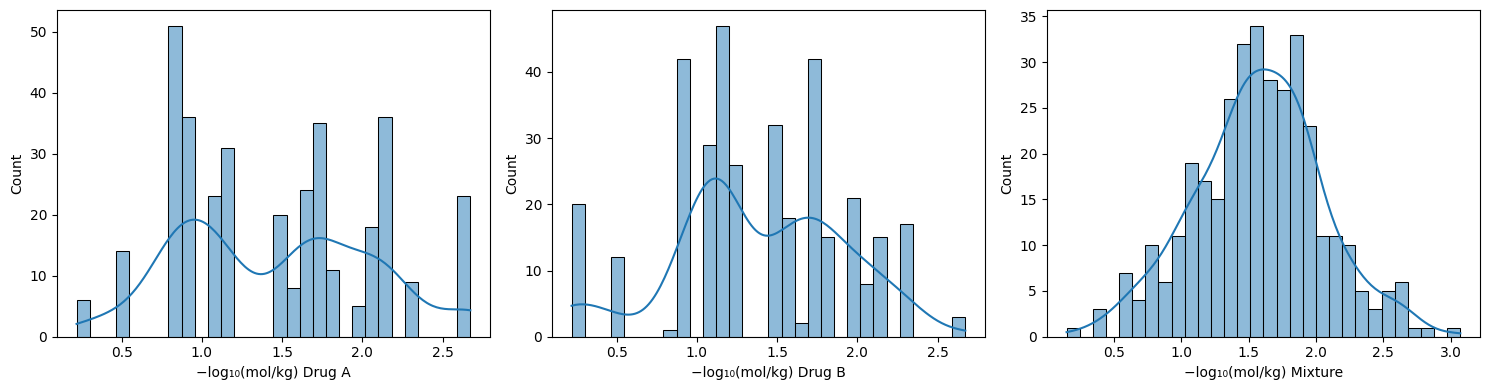

In [12]:
# Histograms
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(df['LD50_A_neglog'], bins=30, kde=True, ax=axes[0])
axes[0].set_xlabel('−log₁₀(mol/kg) Drug A')
sns.histplot(df['LD50_B_neglog'], bins=30, kde=True, ax=axes[1])
axes[1].set_xlabel('−log₁₀(mol/kg) Drug B')
sns.histplot(df['Mixture_neglog'], bins=30, kde=True, ax=axes[2])
axes[2].set_xlabel('−log₁₀(mol/kg) Mixture')
plt.tight_layout()
plt.show()

| neglog_molkg range | Interpretation          |
| ------------------ | ----------------------- |
| **< 1.5**          | very low toxicity       |
| **1.5 to 2.0**     | low toxicity            |
| **2.0 to 2.5**     | moderate toxicity       |
| **2.5 to 3.0**     | high toxicity           |
| **3.0 to 3.5**     | very high toxicity      |
| **> 3.5**          | extremely high toxicity |


## 7. Save the processed dataset

In [13]:
output_path = '/content/drive/MyDrive/FYP/IRP/Data/ddi_ld50_smyth/ddi_ld50_smyth_processed.csv'
df.to_csv(output_path, index=False)
print(f"Saved processed data to {output_path}")

# For modeling, keep only the pair identifiers and mixture toxicity
model_ready = df[['SMILES_A', 'SMILES_B', 'Mixture_neglog']].copy()
model_ready.to_csv('/content/drive/MyDrive/FYP/IRP/Data/ddi_ld50_smyth/ddi_ld50_smyth_model_ready.csv', index=False)

Saved processed data to /content/drive/MyDrive/FYP/IRP/Data/ddi_ld50_smyth/ddi_ld50_smyth_processed.csv


In [14]:
df['Mixture_neglog'].describe()

,Mixture_neglog
count,350.000000
mean,1.574540
std,0.477229
min,0.146880
25%,1.268911
50%,1.586394
75%,1.871728
max,3.072175


In [15]:
df.head()

,DrugA,DrugB,SMILES_A,SMILES_B,LD50_A_mg/kg,LD50_B_mg/kg,Mixture_LD50_mg/kg,MW_A,MW_B,LD50_A_neglog,LD50_B_neglog,Mixture_neglog
0,Acetone,Acetonitrile,CC(=O)C,CC#N,8760.6,6500.22,2055.6535,58.08,41.053,0.821493,0.800417,1.382238
1,Acetone,Acetophenone,CC(=O)C,CC(=O)c1ccccc1,8760.6,2549.44,3091.1650,58.08,120.151,0.821493,1.673283,1.459831
2,Acetone,Acrylonitrile,CC(=O)C,C=CC#N,8760.6,112.84,187.7380,58.08,53.064,0.821493,2.672337,2.471304
3,Acetone,Aniline,CC(=O)C,Nc1ccccc1,8760.6,725.62,1386.8725,58.08,93.129,0.821493,2.108376,1.736511
4,Acetone,Butyl Cellosolve,CC(=O)C,CCCCOCCO,8760.6,2146.76,3064.4355,58.08,118.176,0.821493,1.740746,1.458763


In [16]:
model_ready

,SMILES_A,SMILES_B,Mixture_neglog
0,CC(=O)C,CC#N,1.382238
1,CC(=O)C,CC(=O)c1ccccc1,1.459831
2,CC(=O)C,C=CC#N,2.471304
3,CC(=O)C,Nc1ccccc1,1.736511
4,CC(=O)C,CCCCOCCO,1.458763
...,...,...,...
345,ClC(Cl)=C(Cl)Cl,CC(C)OCC(C)OCC(C)O,1.425159
346,ClC(Cl)=C(Cl)Cl,CC(C)OCC(C)OCC(C)O,1.224722
347,Cc1ccccc1,CC(C)OCC(C)OCC(C)O,1.150740
348,Cc1ccccc1,CC(C)OCC(C)OCC(C)O,1.174694
